# Homework 2: Emergent communication models

This homework assignment is to be completed in groups. It is due on December 18, 2025 (midnight). Please upload *all files you created or modified* to the homework folder of your group in studIP.

Group number:

Names:

*General note: It is permitted to use AI tools for coding. Please refer to the uploaded manual `AI_Tools_Guidelines` for recommended ways how to use AI to advance your studies in a way that supports your learning. That means that you should not be satisfied if an AI tool hands you a working version of your code, but that you should put in effort to understand how exactly the problem is solved. Another note of caution: What might work for large programming languages like Python, does not necessarily work for Stan. Check your code carefully and do NOT blindly trust AI.*

## Introduction
In the past weeks, you learned about classical neural network approaches to modeling language, about Reinforcement learning and how these two can be combined with the aim of modeling communication in the emergent communication modeling framework.
The goal of this homework assignment is to learn to apply these models. You will be working with a Github repository of my own research. Learning how to work with this repository will qualify you for conducting your study project or thesis within this project.
Below, you receive a sample project and are guided through the steps of conducting it. For all steps, it is expected that you comment your code, explain what you are doing and why, and interpret all your outcomes and results. 

## 1) Creating the environment and installing packages (non-graded)
This is a prerequisite for the following tasks and is therefore non-graded. Please let me know if you run into problems with installing everything. Follow the installation guide in the [emergent-abstractions repository](https://github.com/kristinakobrock/emergent-abstractions/tree/main) and validate that you can run the training (with a small number of epochs and dataset). Follow the tutorial in the [Tutorial Github repository](https://github.com/kristinakobrock/tutorial-emergent-abstractions/tree/main) to make yourself familiar with the code.

For the following tasks, you can either work directly with the main repository (recommended) or work with the tutorial code.

```bash
uv init --bare -p 3.9 .
uv add -r .\emergent-abstractions\requirements.txt
uv add git+https://github.com/facebookresearch/EGG.git
uv add ipykernel
```


## 2) Dataset (18 points)
The goal is to implement a hierarchical dataset that follows the following logic from the paper by Hawkins et al., 2018: [Emerging abstractions](https://escholarship.org/uc/item/81s4d7fv)
<img src="img/hierarchy.png" width="400"/>
It differs from the default dataset because the default dataset includes all combinations of objects without implementing a hierarchy. Consider the following example for the default dataset with 3 attributes and 3 values. Concepts are implemented as tuples of objects and fixed vectors which indicate which attributes are relevant to the concept, e.g. ([[2,1,1],[1,0,1],[1,2,1]],(0,0,1)). Where the fixed vector (0,0,1) indicates that only the first attribute is relevant to the concept. [2,1,1],[1,0,1],[1,2,1] are possible objects that satisfy this constraint. You can think of the objects as being a small red circle, a large blue circle and a large green circle - all belonging to the concept 'circle'. Now, in the default dataset, all combinations of attributes are possible, i.e. the higher-level concept don't need to be circles, but could also be the color dimension or the size dimension by specifying the fixed vector as (1,0,0) or (0,1,0). While this certainly makes a lot of sense for compositional features as the ones used here, natural concepts are structured in taxonomic hierarchies (e.g., dalmatian, dog, animal). The goal here is to implement a hierarchical dataset.

### 2.1) Adapting the dataset (12 points)
Adapt the function `get_fixed_vectors` in `dataset.py` to account for hierarchically structured concepts.
Your solution should work for varying dataset sizes and be neatly integrated with the currently available code. Specify a folder where the results for this experiment should be saved to.

### 2.2) Creating the datasets (6 points)
Use the script `pickle_ds.py` to construct 3 datasets with the following attribute-value combinations D(attributes, values):

Use this command to run the script and generate the data results:

D(3,4) means: 
3 = Number of Attributes = Types of features (size, color, shape)
4 = Number of Values = Options per feature (if size: large, medium, small etc)


- D(3,4)
  `python pickle_ds.py --dimensions 4 4 4 --scaling_factor 10 --hierarchical True`\
  output: 
  ```
  Found 3 unique fixed vectors:
   (0, 0, 1)
   (0, 1, 1)
   (1, 1, 1)
  Number of concepts: 84
  ```
- D(4,4)
  `python pickle_ds.py --dimensions 4 4 4 4 --scaling_factor 10 --hierarchical True`\
    output: 
    ```
  Found 4 unique fixed vectors:
   (0, 0, 0, 1)
   (0, 0, 1, 1)
   (0, 1, 1, 1)
   (1, 1, 1, 1)
  Number of concepts: 340
  ```
- D(3,8)
  `python pickle_ds.py --dimensions 8 8 8 --scaling_factor 10 --hierarchical True`\
    output: 
    ```
    Found 3 unique fixed vectors:
    (0, 0, 1)
    (0, 1, 1)
    (1, 1, 1)
    Number of concepts: 584
  ```

In [41]:
!python pickle_ds.py --dimensions 4 4 4 --scaling_factor 10 --hierarchical True 
!python pickle_ds.py --dimensions 4 4 4 4 --scaling_factor 10 --hierarchical True 
!python pickle_ds.py --dimensions 8 8 8 --scaling_factor 10 --hierarchical True 
!python pickle_ds.py --dimensions 4 4 4 --scaling_factor 10 
!python pickle_ds.py --dimensions 4 4 4 4 --scaling_factor 10
!python pickle_ds.py --dimensions 8 8 8 --scaling_factor 10 

Creating train_ds and val_ds...
100%|██████████████████████████████████████████| 67/67 [00:00<00:00, 128.39it/s]

Creating test_ds...
100%|██████████████████████████████████████████| 17/17 [00:00<00:00, 130.74it/s]
Data set is saved as: data/dim(3,4)_sf10_hierarchical.ds
Creating train_ds and val_ds...
100%|█████████████████████████████████████████| 272/272 [00:04<00:00, 60.73it/s]

Creating test_ds...
100%|███████████████████████████████████████████| 68/68 [00:01<00:00, 60.62it/s]
Data set is saved as: data/dim(4,4)_sf10_hierarchical.ds
Creating train_ds and val_ds...
100%|█████████████████████████████████████████| 467/467 [00:07<00:00, 65.81it/s]

Creating test_ds...
100%|█████████████████████████████████████████| 117/117 [00:01<00:00, 65.15it/s]
Data set is saved as: data/dim(3,8)_sf10_hierarchical.ds
Creating train_ds and val_ds...
100%|██████████████████████████████████████████| 99/99 [00:00<00:00, 147.52it/s]

Creating test_ds...
100%|██████████████████████████████████████████| 2

In [42]:
import torch
import pandas as pd
import seaborn


# [3,4] 
with open('data/dim(3,4)_sf10_hierarchical.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_3_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_3_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_3_4):
    print(" ", fixed)

with open('data/dim(3,4)_sf10.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_3_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_3_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_3_4):
    print(" ", fixed)

# [4,4]     
with open('data/dim(4,4)_sf10_hierarchical.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_4_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_4_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_4_4):
    print(" ", fixed)
    
with open('data/dim(4,4)_sf10.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_4_4 = set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_4_4)} unique fixed vectors:")
for fixed in sorted(unique_fixed_4_4):
    print(" ", fixed)

# [3,8] 
with open('data/dim(3,8)_sf10_hierarchical.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_8_3= set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_8_3)} unique fixed vectors:")
for fixed in sorted(unique_fixed_8_3):
    print(" ", fixed)

with open('data/dim(3,8)_sf10.ds', 'rb') as f:
    dataset = torch.load(f, weights_only=False)

print("Is hierarchical?", dataset.hierarchical)  
print("Number of concepts:", len(dataset.concepts))

unique_fixed_8_3= set([concept[1] for concept in dataset.concepts])
print(f"\nFound {len(unique_fixed_8_3)} unique fixed vectors:")
for fixed in sorted(unique_fixed_8_3):
    print(" ", fixed)

Is hierarchical? True
Number of concepts: 84

Found 3 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 1)
  (1, 1, 1)
Is hierarchical? False
Number of concepts: 124

Found 7 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 0)
  (0, 1, 1)
  (1, 0, 0)
  (1, 0, 1)
  (1, 1, 0)
  (1, 1, 1)
Is hierarchical? True
Number of concepts: 340

Found 4 unique fixed vectors:
  (0, 0, 0, 1)
  (0, 0, 1, 1)
  (0, 1, 1, 1)
  (1, 1, 1, 1)
Is hierarchical? False
Number of concepts: 624

Found 15 unique fixed vectors:
  (0, 0, 0, 1)
  (0, 0, 1, 0)
  (0, 0, 1, 1)
  (0, 1, 0, 0)
  (0, 1, 0, 1)
  (0, 1, 1, 0)
  (0, 1, 1, 1)
  (1, 0, 0, 0)
  (1, 0, 0, 1)
  (1, 0, 1, 0)
  (1, 0, 1, 1)
  (1, 1, 0, 0)
  (1, 1, 0, 1)
  (1, 1, 1, 0)
  (1, 1, 1, 1)
Is hierarchical? True
Number of concepts: 584

Found 3 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 1)
  (1, 1, 1)
Is hierarchical? False
Number of concepts: 728

Found 7 unique fixed vectors:
  (0, 0, 1)
  (0, 1, 0)
  (0, 1, 1)
  (1, 0, 0)
  (1, 0, 1)
  (1, 1, 0)
  (1, 1, 1)


## 3) Model simulations (12 points)
Think about which conditions (i.e., settings) you need to compare to discuss whether the implementation of the hierarchical dataset has any measurable impact on the emerging language. Specify which conditions you will compare and why and state your hypotheses. Simulate five runs for each of the datasets and each of the conditions. For hyperparameters, it is recommended to either stick to hyperparameters that were used before (check publications or default settings) or do a grid search over hyperparameters if you expect different hyperparameters to work better.

Settings:
Using the data we created in #2, we compare the control group (non-hierarchical) and the experiment (hierarchical) group.\
We can also reuse the conditions for the dimentions ([3, 3], [3, 4], [4,4], [3, 8]).
- Hierarchical (`hierarchical=True`)
- Non-hierarchical (`hierarchical=False`) as default

Hierarchical:

"dog"       → [A, B, C]\
"brown dog" → [A, B, C, D]  ← Reuses A,B,C, adds D\
"large brown dog" → [A, B, C, D, E]  ← Adds E\

Non-hierarchical:

"dog"       → [A, B, C]\
"brown dog" → [F, G, H]  ← Completely different\
"large brown dog" → [K, L, M]  ← No pattern\

Hypothesis:\
Agents trained on hierarchical datasets will develop more compositional and systematic languages compared to non-hierarchical datasets, because the hierarchical structure provides nested relationships that encourage symbol reuse and compositional message construction.

Hypothesis 1, accuracy:\
Hierarchical has higher accuracy because concepts are structured logically. Agents trained on hierarchical data may achieve higher communicative accuracy, because the structure is easier to generalize.
Hypothesis 2, message length:\ 
Messages in hierarchical condition will be shorter because they can refer to higher-level concepts.

Hypothesis 3, NMI :\
Hierarchical condition will show higher NMI (better alignment between messages and concepts) as the target itself is always specific. They may fail to develop abstract terms effectively because they are never explicitly trained to group objects.


### Default Runs

#### DIM(3,4)_SF10

In [44]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 0 --save True

data loaded from: data/dim(3,4)_sf10.ds
vocab size 16
message length 3
{"loss": 0.6766272187232971, "acc": 0.5659072995185852, "length": 3.03836989402771, "mode": "train", "epoch": 1}
{"loss": 0.6148641109466553, "acc": 0.658393144607544, "length": 3.328125, "mode": "test", "epoch": 1}
{"loss": 0.5407211780548096, "acc": 0.7297900915145874, "length": 3.820312738418579, "mode": "train", "epoch": 2}
{"loss": 0.5345509052276611, "acc": 0.7327257394790649, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.44894278049468994, "acc": 0.79898601770401, "length": 3.950936794281006, "mode": "train", "epoch": 3}
{"loss": 0.45054101943969727, "acc": 0.8198784589767456, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.35743647813796997, "acc": 0.8473808765411377, "length": 3.980692148208618, "mode": "train", "epoch": 4}
{"loss": 0.4180894196033478, "acc": 0.8190972805023193, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.3168889880180359, "acc": 0.8654265999794006, "length": 3.99072

In [45]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 1 --save True

data loaded from: data/dim(3,4)_sf10.ds
vocab size 16
message length 3
{"loss": 0.6880466341972351, "acc": 0.5389724373817444, "length": 3.0551695823669434, "mode": "train", "epoch": 1}
{"loss": 0.6254497766494751, "acc": 0.6723036170005798, "length": 3.4270832538604736, "mode": "test", "epoch": 1}
{"loss": 0.5183478593826294, "acc": 0.7532872557640076, "length": 3.596437692642212, "mode": "train", "epoch": 2}
{"loss": 0.5028946399688721, "acc": 0.7807238101959229, "length": 3.9982638359069824, "mode": "test", "epoch": 2}
{"loss": 0.4460675120353699, "acc": 0.7971068620681763, "length": 3.8829314708709717, "mode": "train", "epoch": 3}
{"loss": 0.46670621633529663, "acc": 0.7810763120651245, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.4236859679222107, "acc": 0.8129204511642456, "length": 3.9608044624328613, "mode": "train", "epoch": 4}
{"loss": 0.4392116665840149, "acc": 0.8042534589767456, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.40020447969436646, "acc": 0.8219

In [46]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 2 --save True

data loaded from: data/dim(3,4)_sf10.ds
vocab size 16
message length 3
{"loss": 0.6708973050117493, "acc": 0.5782167315483093, "length": 3.5460689067840576, "mode": "train", "epoch": 1}
{"loss": 0.6125004291534424, "acc": 0.6754339933395386, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.5567377209663391, "acc": 0.6969245672225952, "length": 3.932225227355957, "mode": "train", "epoch": 2}
{"loss": 0.5483148694038391, "acc": 0.6811631917953491, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.5084929466247559, "acc": 0.7415949702262878, "length": 3.9623098373413086, "mode": "train", "epoch": 3}
{"loss": 0.5406644344329834, "acc": 0.734375, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.4410703778266907, "acc": 0.8001477718353271, "length": 3.9767608642578125, "mode": "train", "epoch": 4}
{"loss": 0.5468906164169312, "acc": 0.7477430701255798, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.3938465714454651, "acc": 0.8228716850280762, "length": 3.9909884929656982

In [47]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 3 --save True

data loaded from: data/dim(3,4)_sf10.ds
vocab size 16
message length 3
{"loss": 0.67624831199646, "acc": 0.5724024176597595, "length": 3.127178430557251, "mode": "train", "epoch": 1}
{"loss": 0.591046929359436, "acc": 0.7022542357444763, "length": 3.409722328186035, "mode": "test", "epoch": 1}
{"loss": 0.519485354423523, "acc": 0.7516188025474548, "length": 3.7909183502197266, "mode": "train", "epoch": 2}
{"loss": 0.5082228183746338, "acc": 0.7844617962837219, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.45071443915367126, "acc": 0.8059719204902649, "length": 3.9712319374084473, "mode": "train", "epoch": 3}
{"loss": 0.4596647620201111, "acc": 0.7980034947395325, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.41512787342071533, "acc": 0.81902676820755, "length": 3.984636068344116, "mode": "train", "epoch": 4}
{"loss": 0.4229477047920227, "acc": 0.8125868439674377, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.3830518424510956, "acc": 0.8384048342704773, "length":

In [48]:
!python train.py --load_dataset "dim(3,4)_sf10.ds" --random_seed 4 --save True

data loaded from: data/dim(3,4)_sf10.ds
vocab size 16
message length 3
{"loss": 0.6788612008094788, "acc": 0.5629165768623352, "length": 3.070103883743286, "mode": "train", "epoch": 1}
{"loss": 0.6223714351654053, "acc": 0.6771376132965088, "length": 2.6857638359069824, "mode": "test", "epoch": 1}
{"loss": 0.5490536689758301, "acc": 0.7283412218093872, "length": 3.4407901763916016, "mode": "train", "epoch": 2}
{"loss": 0.5201677083969116, "acc": 0.7509331107139587, "length": 3.8020832538604736, "mode": "test", "epoch": 2}
{"loss": 0.476256400346756, "acc": 0.7746647000312805, "length": 3.7384793758392334, "mode": "train", "epoch": 3}
{"loss": 0.5006459951400757, "acc": 0.7784857749938965, "length": 3.680555582046509, "mode": "test", "epoch": 3}
{"loss": 0.43027499318122864, "acc": 0.8027827143669128, "length": 3.7765018939971924, "mode": "train", "epoch": 4}
{"loss": 0.4586866796016693, "acc": 0.8021158576011658, "length": 3.8263888359069824, "mode": "test", "epoch": 4}
{"loss": 0.3646

#### DIM(4,4)_SF10

In [49]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 0 --save True

data loaded from: data/dim(4,4)_sf10.ds
vocab size 16
message length 4
{"loss": 0.5123339295387268, "acc": 0.7315115928649902, "length": 4.284569263458252, "mode": "train", "epoch": 1}
{"loss": 0.4194253385066986, "acc": 0.8055064678192139, "length": 5.0, "mode": "test", "epoch": 1}
{"loss": 0.34239277243614197, "acc": 0.8541697263717651, "length": 4.994505405426025, "mode": "train", "epoch": 2}
{"loss": 0.3533575236797333, "acc": 0.8502393960952759, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.29127824306488037, "acc": 0.8825823068618774, "length": 4.9981231689453125, "mode": "train", "epoch": 3}
{"loss": 0.3377266824245453, "acc": 0.8585937023162842, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.2609127461910248, "acc": 0.8944615125656128, "length": 4.998770236968994, "mode": "train", "epoch": 4}
{"loss": 0.30732494592666626, "acc": 0.87294602394104, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.23949968814849854, "acc": 0.9038784503936768, "length": 4.999157

In [50]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 1 --save True

data loaded from: data/dim(4,4)_sf10.ds
vocab size 16
message length 4
{"loss": 0.5256838202476501, "acc": 0.7258378863334656, "length": 4.185116291046143, "mode": "train", "epoch": 1}
{"loss": 0.4448082149028778, "acc": 0.7857233881950378, "length": 5.0, "mode": "test", "epoch": 1}
{"loss": 0.40111950039863586, "acc": 0.812746524810791, "length": 4.990119934082031, "mode": "train", "epoch": 2}
{"loss": 0.36881884932518005, "acc": 0.8325101137161255, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.34206897020339966, "acc": 0.8460367918014526, "length": 4.997544765472412, "mode": "train", "epoch": 3}
{"loss": 0.3541199564933777, "acc": 0.8383442759513855, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.3122202754020691, "acc": 0.862417995929718, "length": 4.998910427093506, "mode": "train", "epoch": 4}
{"loss": 0.3497617542743683, "acc": 0.8290448784828186, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.2927291989326477, "acc": 0.8729877471923828, "length": 4.99940204

In [51]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 2 --save True

data loaded from: data/dim(4,4)_sf10.ds
vocab size 16
message length 4
{"loss": 0.49715790152549744, "acc": 0.7415604591369629, "length": 4.340274333953857, "mode": "train", "epoch": 1}
{"loss": 0.5121695399284363, "acc": 0.7730720639228821, "length": 5.0, "mode": "test", "epoch": 1}
{"loss": 0.3100741505622864, "acc": 0.870407223701477, "length": 4.993471622467041, "mode": "train", "epoch": 2}
{"loss": 0.45474401116371155, "acc": 0.7866935133934021, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.2414471060037613, "acc": 0.9046311974525452, "length": 4.9976372718811035, "mode": "train", "epoch": 3}
{"loss": 0.4858382046222687, "acc": 0.7915448546409607, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.20204968750476837, "acc": 0.9251315593719482, "length": 4.998924255371094, "mode": "train", "epoch": 4}
{"loss": 0.38776522874832153, "acc": 0.8450731039047241, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.17642371356487274, "acc": 0.936782717704773, "length": 4.99936

In [52]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 3 --save True

data loaded from: data/dim(4,4)_sf10.ds
vocab size 16
message length 4
{"loss": 0.5082640647888184, "acc": 0.7321275472640991, "length": 4.146275043487549, "mode": "train", "epoch": 1}
{"loss": 0.5000337958335876, "acc": 0.7770916819572449, "length": 5.0, "mode": "test", "epoch": 1}
{"loss": 0.2998424470424652, "acc": 0.8756914734840393, "length": 4.989643573760986, "mode": "train", "epoch": 2}
{"loss": 0.5563403367996216, "acc": 0.7609626650810242, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.2352161705493927, "acc": 0.9082929491996765, "length": 4.9961137771606445, "mode": "train", "epoch": 3}
{"loss": 0.46973761916160583, "acc": 0.7962449789047241, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.20108523964881897, "acc": 0.9233192801475525, "length": 4.997814655303955, "mode": "train", "epoch": 4}
{"loss": 0.3386974632740021, "acc": 0.8596521615982056, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.17479248344898224, "acc": 0.9350541234016418, "length": 4.99826

In [53]:
!python train.py --load_dataset "dim(4,4)_sf10.ds" --random_seed 4 --save True

data loaded from: data/dim(4,4)_sf10.ds
vocab size 16
message length 4
{"loss": 0.5089249014854431, "acc": 0.7348738312721252, "length": 4.516394138336182, "mode": "train", "epoch": 1}
{"loss": 0.4586147367954254, "acc": 0.7822958827018738, "length": 5.0, "mode": "test", "epoch": 1}
{"loss": 0.3711526691913605, "acc": 0.8357469439506531, "length": 4.995999336242676, "mode": "train", "epoch": 2}
{"loss": 0.3784148395061493, "acc": 0.836794376373291, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.3123423457145691, "acc": 0.8651959300041199, "length": 4.998315811157227, "mode": "train", "epoch": 3}
{"loss": 0.3573460876941681, "acc": 0.83012855052948, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.2807992398738861, "acc": 0.8802732229232788, "length": 4.999170303344727, "mode": "train", "epoch": 4}
{"loss": 0.3075800836086273, "acc": 0.8646547794342041, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.251658171415329, "acc": 0.895624041557312, "length": 4.99945116043090

#### DIM(3,8)_SF10

In [54]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 0 --save True

data loaded from: data/dim(3,8)_sf10.ds
vocab size 28
message length 3
{"loss": 0.5782591700553894, "acc": 0.6720608472824097, "length": 2.8208541870117188, "mode": "train", "epoch": 1}
{"loss": 0.5027654767036438, "acc": 0.7457544207572937, "length": 3.3984375, "mode": "test", "epoch": 1}
{"loss": 0.4454565644264221, "acc": 0.7953014373779297, "length": 3.838287830352783, "mode": "train", "epoch": 2}
{"loss": 0.4270479381084442, "acc": 0.806106686592102, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.38817650079727173, "acc": 0.8277894854545593, "length": 3.996647357940674, "mode": "train", "epoch": 3}
{"loss": 0.38956746459007263, "acc": 0.8269661068916321, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.34629175066947937, "acc": 0.8521959781646729, "length": 3.9984755516052246, "mode": "train", "epoch": 4}
{"loss": 0.35406431555747986, "acc": 0.8513151407241821, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.30890417098999023, "acc": 0.8733314275741577, "length":

In [55]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 1 --save True

data loaded from: data/dim(3,8)_sf10.ds
vocab size 28
message length 3
{"loss": 0.5428175926208496, "acc": 0.7109641432762146, "length": 3.8080108165740967, "mode": "train", "epoch": 1}
{"loss": 0.4725131392478943, "acc": 0.7717317938804626, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.40413370728492737, "acc": 0.8264921307563782, "length": 3.9983818531036377, "mode": "train", "epoch": 2}
{"loss": 0.40735167264938354, "acc": 0.8179426789283752, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.32736533880233765, "acc": 0.8665676712989807, "length": 3.999281644821167, "mode": "train", "epoch": 3}
{"loss": 0.3575698733329773, "acc": 0.8527994751930237, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.2692554295063019, "acc": 0.8956427574157715, "length": 3.999579429626465, "mode": "train", "epoch": 4}
{"loss": 0.3082324266433716, "acc": 0.8771613836288452, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.23875294625759125, "acc": 0.911022961139679, "length": 3.9997

In [56]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 2 --save True

data loaded from: data/dim(3,8)_sf10.ds
vocab size 28
message length 3
{"loss": 0.5466939210891724, "acc": 0.7086541056632996, "length": 3.845708131790161, "mode": "train", "epoch": 1}
{"loss": 0.48531919717788696, "acc": 0.770911455154419, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.3849620223045349, "acc": 0.8362975120544434, "length": 3.9983885288238525, "mode": "train", "epoch": 2}
{"loss": 0.4525868594646454, "acc": 0.800507664680481, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.3237847089767456, "acc": 0.8640823364257812, "length": 3.999486207962036, "mode": "train", "epoch": 3}
{"loss": 0.37029168009757996, "acc": 0.8386198282241821, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.2866661250591278, "acc": 0.8846392631530762, "length": 3.9996933937072754, "mode": "train", "epoch": 4}
{"loss": 0.33714941143989563, "acc": 0.8603255748748779, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.2570210099220276, "acc": 0.900797426700592, "length": 3.9997684

In [57]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 3 --save True

data loaded from: data/dim(3,8)_sf10.ds
vocab size 28
message length 3
{"loss": 0.529325008392334, "acc": 0.717579185962677, "length": 3.466085910797119, "mode": "train", "epoch": 1}
{"loss": 0.4268624484539032, "acc": 0.8088541626930237, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.38742658495903015, "acc": 0.8284467458724976, "length": 3.9957387447357178, "mode": "train", "epoch": 2}
{"loss": 0.3916562497615814, "acc": 0.8273437023162842, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.3431553840637207, "acc": 0.8558765053749084, "length": 3.9980013370513916, "mode": "train", "epoch": 3}
{"loss": 0.3531656563282013, "acc": 0.8487760424613953, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.3113456666469574, "acc": 0.870822548866272, "length": 3.9992082118988037, "mode": "train", "epoch": 4}
{"loss": 0.3362728953361511, "acc": 0.8532812595367432, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.29151612520217896, "acc": 0.8810040950775146, "length": 3.9995529

In [58]:
!python train.py --load_dataset "dim(3,8)_sf10.ds" --random_seed 4 --save True

data loaded from: data/dim(3,8)_sf10.ds
vocab size 28
message length 3
{"loss": 0.5305824279785156, "acc": 0.7179157137870789, "length": 3.6493842601776123, "mode": "train", "epoch": 1}
{"loss": 0.48869940638542175, "acc": 0.7735286951065063, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.3323858380317688, "acc": 0.8605136275291443, "length": 3.996781349182129, "mode": "train", "epoch": 2}
{"loss": 0.38033077120780945, "acc": 0.8318489789962769, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.27330902218818665, "acc": 0.8906904458999634, "length": 3.9987895488739014, "mode": "train", "epoch": 3}
{"loss": 0.3569258153438568, "acc": 0.8407291769981384, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.24561172723770142, "acc": 0.9082231521606445, "length": 3.999340295791626, "mode": "train", "epoch": 4}
{"loss": 0.3136630654335022, "acc": 0.8736066818237305, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.22307664155960083, "acc": 0.9202698469161987, "length": 3.99

### Hierarchical Runs

#### DIM(3,4)_SF10

In [59]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 0 --save True

data loaded from: data/dim(3,4)_sf10_hierarchical.ds
vocab size 16
message length 3
{"loss": 0.6897146105766296, "acc": 0.539333164691925, "length": 3.035269260406494, "mode": "train", "epoch": 1}
{"loss": 0.6566174626350403, "acc": 0.6271658539772034, "length": 1.8169642686843872, "mode": "test", "epoch": 1}
{"loss": 0.5839361548423767, "acc": 0.6955475807189941, "length": 2.359473705291748, "mode": "train", "epoch": 2}
{"loss": 0.5308560132980347, "acc": 0.7531145215034485, "length": 2.3058035373687744, "mode": "test", "epoch": 2}
{"loss": 0.4661247730255127, "acc": 0.7794999480247498, "length": 3.4312329292297363, "mode": "train", "epoch": 3}
{"loss": 0.43392786383628845, "acc": 0.8056920766830444, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.37875857949256897, "acc": 0.8479985594749451, "length": 3.985992670059204, "mode": "train", "epoch": 4}
{"loss": 0.41506847739219666, "acc": 0.8250001072883606, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.34916630387306213, "

In [60]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 1 --save True

data loaded from: data/dim(3,4)_sf10_hierarchical.ds
vocab size 16
message length 3
{"loss": 0.6886938810348511, "acc": 0.5334813594818115, "length": 3.23701548576355, "mode": "train", "epoch": 1}
{"loss": 0.6471037268638611, "acc": 0.6478166580200195, "length": 3.752232074737549, "mode": "test", "epoch": 1}
{"loss": 0.56352698802948, "acc": 0.7051892280578613, "length": 3.8268420696258545, "mode": "train", "epoch": 2}
{"loss": 0.5273207426071167, "acc": 0.7191964387893677, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.5244540572166443, "acc": 0.7178221344947815, "length": 3.9707746505737305, "mode": "train", "epoch": 3}
{"loss": 0.5191135406494141, "acc": 0.7312499284744263, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.5077220797538757, "acc": 0.7294104099273682, "length": 3.972473621368408, "mode": "train", "epoch": 4}
{"loss": 0.4811401963233948, "acc": 0.7437499165534973, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.44487079977989197, "acc": 0.800684511661

In [61]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 2 --save True

data loaded from: data/dim(3,4)_sf10_hierarchical.ds
vocab size 16
message length 3
{"loss": 0.6904340982437134, "acc": 0.5395439863204956, "length": 3.1765100955963135, "mode": "train", "epoch": 1}
{"loss": 0.6594958305358887, "acc": 0.6289759874343872, "length": 2.2924106121063232, "mode": "test", "epoch": 1}
{"loss": 0.5742951035499573, "acc": 0.7139710783958435, "length": 3.042241334915161, "mode": "train", "epoch": 2}
{"loss": 0.49004364013671875, "acc": 0.7704485654830933, "length": 3.4107143878936768, "mode": "test", "epoch": 2}
{"loss": 0.4342256486415863, "acc": 0.8111056089401245, "length": 3.377462148666382, "mode": "train", "epoch": 3}
{"loss": 0.4329196810722351, "acc": 0.8047642111778259, "length": 3.7589285373687744, "mode": "test", "epoch": 3}
{"loss": 0.3525088429450989, "acc": 0.8583644032478333, "length": 3.580582857131958, "mode": "train", "epoch": 4}
{"loss": 0.36558079719543457, "acc": 0.8331612944602966, "length": 3.892857074737549, "mode": "test", "epoch": 4}
{"

In [62]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 3 --save True

data loaded from: data/dim(3,4)_sf10_hierarchical.ds
vocab size 16
message length 3
{"loss": 0.6917210817337036, "acc": 0.5334229469299316, "length": 2.7689971923828125, "mode": "train", "epoch": 1}
{"loss": 0.6664839386940002, "acc": 0.6187918782234192, "length": 1.9709821939468384, "mode": "test", "epoch": 1}
{"loss": 0.5839970707893372, "acc": 0.7110222578048706, "length": 2.719487428665161, "mode": "train", "epoch": 2}
{"loss": 0.48961228132247925, "acc": 0.7684012651443481, "length": 3.5513393878936768, "mode": "test", "epoch": 2}
{"loss": 0.4242411255836487, "acc": 0.8082334399223328, "length": 3.8333053588867188, "mode": "train", "epoch": 3}
{"loss": 0.41810837388038635, "acc": 0.8223214745521545, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.3812791109085083, "acc": 0.8357183337211609, "length": 3.981966972351074, "mode": "train", "epoch": 4}
{"loss": 0.4443524181842804, "acc": 0.8146205544471741, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.36744099855422974, 

In [63]:
!python train.py --load_dataset "dim(3,4)_sf10_hierarchical.ds" --random_seed 4 --save True

data loaded from: data/dim(3,4)_sf10_hierarchical.ds
vocab size 16
message length 3
{"loss": 0.6902607083320618, "acc": 0.5438312888145447, "length": 2.9008917808532715, "mode": "train", "epoch": 1}
{"loss": 0.6562702059745789, "acc": 0.6454973816871643, "length": 2.205357074737549, "mode": "test", "epoch": 1}
{"loss": 0.5983554124832153, "acc": 0.679101288318634, "length": 2.824924945831299, "mode": "train", "epoch": 2}
{"loss": 0.5348331928253174, "acc": 0.755566418170929, "length": 2.7142856121063232, "mode": "test", "epoch": 2}
{"loss": 0.4452216625213623, "acc": 0.7962241172790527, "length": 3.530268669128418, "mode": "train", "epoch": 3}
{"loss": 0.39163050055503845, "acc": 0.8376464247703552, "length": 3.9263393878936768, "mode": "test", "epoch": 3}
{"loss": 0.3524148762226105, "acc": 0.8569896817207336, "length": 3.926071882247925, "mode": "train", "epoch": 4}
{"loss": 0.3556966781616211, "acc": 0.8552455902099609, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.324351787

#### DIM(4,4)_SF10

In [64]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 0 --save True

data loaded from: data/dim(4,4)_sf10_hierarchical.ds
vocab size 16
message length 4
{"loss": 0.5299524664878845, "acc": 0.7144296169281006, "length": 3.7284650802612305, "mode": "train", "epoch": 1}
{"loss": 0.41135329008102417, "acc": 0.8298044204711914, "length": 4.555689334869385, "mode": "test", "epoch": 1}
{"loss": 0.362342894077301, "acc": 0.8537911772727966, "length": 4.889214038848877, "mode": "train", "epoch": 2}
{"loss": 0.38590383529663086, "acc": 0.8475761413574219, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.31922128796577454, "acc": 0.8738546371459961, "length": 4.9892778396606445, "mode": "train", "epoch": 3}
{"loss": 0.36286699771881104, "acc": 0.8433493375778198, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.3013497292995453, "acc": 0.8787802457809448, "length": 4.9926958084106445, "mode": "train", "epoch": 4}
{"loss": 0.3140581548213959, "acc": 0.8821314573287964, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.2881326675415039, "acc": 0.881866

In [65]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 1 --save True

data loaded from: data/dim(4,4)_sf10_hierarchical.ds
vocab size 16
message length 4
{"loss": 0.5502654314041138, "acc": 0.702262282371521, "length": 4.00946044921875, "mode": "train", "epoch": 1}
{"loss": 0.4369516670703888, "acc": 0.8077517747879028, "length": 4.837339878082275, "mode": "test", "epoch": 1}
{"loss": 0.3416154384613037, "acc": 0.863892138004303, "length": 4.91404390335083, "mode": "train", "epoch": 2}
{"loss": 0.36882784962654114, "acc": 0.8515024185180664, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.2859616279602051, "acc": 0.8812128305435181, "length": 4.98935079574585, "mode": "train", "epoch": 3}
{"loss": 0.29264000058174133, "acc": 0.8779447674751282, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.2480972558259964, "acc": 0.9002969861030579, "length": 4.995815277099609, "mode": "train", "epoch": 4}
{"loss": 0.266377717256546, "acc": 0.8872596621513367, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.22179830074310303, "acc": 0.911165118217468

In [66]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 2 --save True

data loaded from: data/dim(4,4)_sf10_hierarchical.ds
vocab size 16
message length 4
{"loss": 0.5022214651107788, "acc": 0.733796238899231, "length": 4.33401346206665, "mode": "train", "epoch": 1}
{"loss": 0.405010461807251, "acc": 0.819363534450531, "length": 4.726362228393555, "mode": "test", "epoch": 1}
{"loss": 0.32323676347732544, "acc": 0.8716402649879456, "length": 4.913047790527344, "mode": "train", "epoch": 2}
{"loss": 0.4984026551246643, "acc": 0.7909855246543884, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.2652719020843506, "acc": 0.897034227848053, "length": 4.994705677032471, "mode": "train", "epoch": 3}
{"loss": 0.34180372953414917, "acc": 0.8842347860336304, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.2318931221961975, "acc": 0.9085585474967957, "length": 4.996630668640137, "mode": "train", "epoch": 4}
{"loss": 0.3853176236152649, "acc": 0.8330528140068054, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.20665225386619568, "acc": 0.92148137092590

In [67]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 3 --save True

data loaded from: data/dim(4,4)_sf10_hierarchical.ds
vocab size 16
message length 4
{"loss": 0.5382462739944458, "acc": 0.7010085582733154, "length": 3.46764874458313, "mode": "train", "epoch": 1}
{"loss": 0.9077858328819275, "acc": 0.7225084900856018, "length": 4.995192527770996, "mode": "test", "epoch": 1}
{"loss": 0.3065720796585083, "acc": 0.8834550380706787, "length": 4.820732116699219, "mode": "train", "epoch": 2}
{"loss": 0.3703088164329529, "acc": 0.8381010293960571, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.25703486800193787, "acc": 0.907422661781311, "length": 4.975297451019287, "mode": "train", "epoch": 3}
{"loss": 0.33379387855529785, "acc": 0.8423678278923035, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.2321932017803192, "acc": 0.9146296977996826, "length": 4.985506534576416, "mode": "train", "epoch": 4}
{"loss": 0.27762579917907715, "acc": 0.8793269395828247, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.2140059769153595, "acc": 0.91707229614

In [68]:
!python train.py --load_dataset "dim(4,4)_sf10_hierarchical.ds" --random_seed 4 --save True

data loaded from: data/dim(4,4)_sf10_hierarchical.ds
vocab size 16
message length 4
{"loss": 0.5278527140617371, "acc": 0.7146146893501282, "length": 4.260530948638916, "mode": "train", "epoch": 1}
{"loss": 0.42010366916656494, "acc": 0.8102564215660095, "length": 5.0, "mode": "test", "epoch": 1}
{"loss": 0.3228643536567688, "acc": 0.8730825781822205, "length": 4.991855144500732, "mode": "train", "epoch": 2}
{"loss": 0.4392703175544739, "acc": 0.8019230961799622, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.2547878324985504, "acc": 0.9052127599716187, "length": 4.994939804077148, "mode": "train", "epoch": 3}
{"loss": 0.32808688282966614, "acc": 0.8562098741531372, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.2168351262807846, "acc": 0.9231504797935486, "length": 4.996870517730713, "mode": "train", "epoch": 4}
{"loss": 0.3130286633968353, "acc": 0.8795071244239807, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.19706381857395172, "acc": 0.9284050464630127, "leng

#### DIM(3,8)_SF10

In [69]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 0 --save True

data loaded from: data/dim(3,8)_sf10_hierarchical.ds
vocab size 28
message length 3
{"loss": 0.5232542753219604, "acc": 0.7214769124984741, "length": 3.5835208892822266, "mode": "train", "epoch": 1}
{"loss": 0.43808844685554504, "acc": 0.7864934206008911, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.31726160645484924, "acc": 0.8769310116767883, "length": 3.995893955230713, "mode": "train", "epoch": 2}
{"loss": 0.38362443447113037, "acc": 0.8174880146980286, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.2694922387599945, "acc": 0.8974460959434509, "length": 3.9982423782348633, "mode": "train", "epoch": 3}
{"loss": 0.3789784610271454, "acc": 0.8449669480323792, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.2449897974729538, "acc": 0.9073705077171326, "length": 3.9990639686584473, "mode": "train", "epoch": 4}
{"loss": 0.3554900586605072, "acc": 0.8279145956039429, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.22393132746219635, "acc": 0.9153091311454773, "

In [70]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 1 --save True

data loaded from: data/dim(3,8)_sf10_hierarchical.ds
vocab size 28
message length 3
{"loss": 0.5225384831428528, "acc": 0.7214091420173645, "length": 3.6806185245513916, "mode": "train", "epoch": 1}
{"loss": 0.4053288996219635, "acc": 0.8229867219924927, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.3584398627281189, "acc": 0.8539645075798035, "length": 3.9970223903656006, "mode": "train", "epoch": 2}
{"loss": 0.38861435651779175, "acc": 0.8285306096076965, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.31957370042800903, "acc": 0.8777355551719666, "length": 3.9984068870544434, "mode": "train", "epoch": 3}
{"loss": 0.33055683970451355, "acc": 0.87173992395401, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.296160489320755, "acc": 0.8890107274055481, "length": 3.998872756958008, "mode": "train", "epoch": 4}
{"loss": 0.3050626516342163, "acc": 0.8812649250030518, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.2780754268169403, "acc": 0.8962923288345337, "leng

In [71]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 2 --save True

data loaded from: data/dim(3,8)_sf10_hierarchical.ds
vocab size 28
message length 3
{"loss": 0.5242306590080261, "acc": 0.7206763625144958, "length": 3.534236192703247, "mode": "train", "epoch": 1}
{"loss": 0.40734684467315674, "acc": 0.8119591474533081, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.3514738380908966, "acc": 0.8603851199150085, "length": 3.99423885345459, "mode": "train", "epoch": 2}
{"loss": 0.40305855870246887, "acc": 0.821108877658844, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.30479350686073303, "acc": 0.8828126788139343, "length": 3.997591257095337, "mode": "train", "epoch": 3}
{"loss": 0.3675573766231537, "acc": 0.8419471979141235, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.27609869837760925, "acc": 0.8974209427833557, "length": 3.998724937438965, "mode": "train", "epoch": 4}
{"loss": 0.3461836278438568, "acc": 0.8522084951400757, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.25047749280929565, "acc": 0.910045862197876, "lengt

In [72]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 3 --save True

data loaded from: data/dim(3,8)_sf10_hierarchical.ds
vocab size 28
message length 3
{"loss": 0.5182470679283142, "acc": 0.7256952524185181, "length": 3.494843006134033, "mode": "train", "epoch": 1}
{"loss": 0.4339030086994171, "acc": 0.7990685701370239, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.3705200254917145, "acc": 0.8450727462768555, "length": 3.994213104248047, "mode": "train", "epoch": 2}
{"loss": 0.38097378611564636, "acc": 0.8405498266220093, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.33122220635414124, "acc": 0.8690442442893982, "length": 3.996500253677368, "mode": "train", "epoch": 3}
{"loss": 0.3318379819393158, "acc": 0.8700270056724548, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.30080685019493103, "acc": 0.8811338543891907, "length": 3.997411012649536, "mode": "train", "epoch": 4}
{"loss": 0.308512419462204, "acc": 0.8766075968742371, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.28558361530303955, "acc": 0.8831139206886292, "leng

In [73]:
!python train.py --load_dataset "dim(3,8)_sf10_hierarchical.ds" --random_seed 4 --save True

data loaded from: data/dim(3,8)_sf10_hierarchical.ds
vocab size 28
message length 3
{"loss": 0.5241064429283142, "acc": 0.7178019881248474, "length": 3.7183637619018555, "mode": "train", "epoch": 1}
{"loss": 0.4194161295890808, "acc": 0.8239182829856873, "length": 4.0, "mode": "test", "epoch": 1}
{"loss": 0.387993723154068, "acc": 0.8352155089378357, "length": 3.9968185424804688, "mode": "train", "epoch": 2}
{"loss": 0.38652971386909485, "acc": 0.8422626852989197, "length": 4.0, "mode": "test", "epoch": 2}
{"loss": 0.3344396948814392, "acc": 0.8652219772338867, "length": 3.9983792304992676, "mode": "train", "epoch": 3}
{"loss": 0.3556519150733948, "acc": 0.8441857099533081, "length": 4.0, "mode": "test", "epoch": 3}
{"loss": 0.29751044511795044, "acc": 0.8839067220687866, "length": 3.99902081489563, "mode": "train", "epoch": 4}
{"loss": 0.33825236558914185, "acc": 0.8604418039321899, "length": 4.0, "mode": "test", "epoch": 4}
{"loss": 0.2732123136520386, "acc": 0.8924033641815186, "len


## 4) Analysis (50 points)
### 4.1) Model performance (10 points)

Assess the model performance for each dataset and condition.

#### D(3, 4)
Performance results:
The non-hierarchical condition achieved higher test accuracy (0.9073 ± 0.0316) than the hierarchical condition (0.8849 ± 0.0493).
Test loss was lower in the non-hierarchical condition (0.2393 ± 0.0662 vs. 0.2717 ± 0.0789).
The hierarchical condition shows higher variance, suggesting less stable learning.

Interpretation
Hierarchical structure appears to increase learning difficulty in D(3,4).
This suggests that hierarchical constraints may impose additional cognitive or representational demands as dataset complexity increases.
Importantly, despite slightly lower accuracy, hierarchical agents still reach high performance, indicating successful task learning.


### 4.2) Quantitative analysis (25 points)

Analyze the emerging languages in your conditions with metrics as you see fit. You can check out the emergent-abstractions github repository for inspiration. Your analysis should at least include the following metrics:

   - NMI
   - message length

Choose two additional metrics or types of quantitative analysis and interpret all your results.
### 4.3) Qualitative analysis (15 points)

Look at the emerging messages and concepts from the interaction files (see tutorial). Assess the differences between simulations with and without the hierarchical datasets. Can you make out specific test cases where the results (should) differ? Come up with a good way to visualize your results, either as a tidy table, or a visual representation, for example with clustering methods.


### PLOT

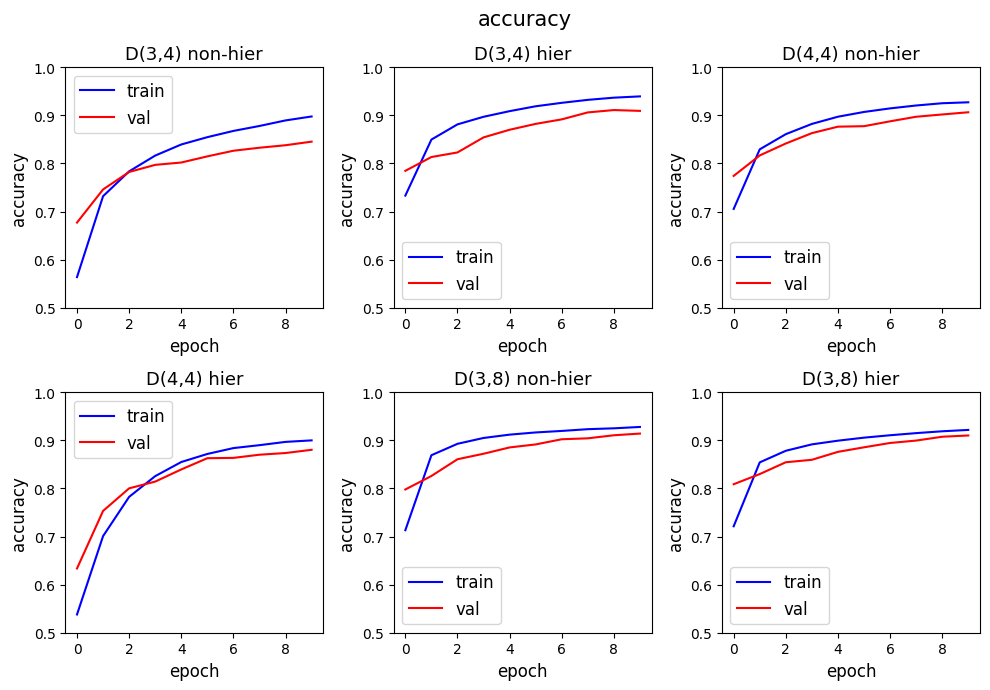

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Performance utilities
from utils.load_results import load_accuracies
from utils.plot_helpers import plot_training_trajectory
from utils.analysis_from_interaction import *

# -----------------------------
# Configuration
# -----------------------------
RESULTS_DIR = "results/(3,4)_game_size_10_vsf_3"

# 5 runs per condition
RUN_MAP = {
    "(3,4)_nonhier": list(range(0, 5)),
    "(3,4)_hier":    list(range(5, 10)),
    "(4,4)_nonhier": list(range(10, 15)),
    "(4,4)_hier":    list(range(15, 20)),
    "(3,8)_nonhier": list(range(20, 25)),
    "(3,8)_hier":    list(range(25, 30)),

}

# Plot order and titles
ORDER = [
    "(3,4)_nonhier", "(3,4)_hier",
    "(4,4)_nonhier", "(4,4)_hier",
    "(3,8)_nonhier", "(3,8)_hier",
]

TITLES = [
    "D(3,4) non-hier", "D(3,4) hier",
    "D(4,4) non-hier", "D(4,4) hier",
    "D(3,8) non-hier", "D(3,8) hier",
]

n_epochs = 10  # number of epochs in this run

# -----------------------------
# Load accuracies
# -----------------------------
all_accuracies = load_accuracies(
    all_paths=[RESULTS_DIR],
    n_runs=30,  # total runs
    n_epochs=n_epochs,
    val_steps=1,
    context_unaware=False
)

# -----------------------------
# Helper functions
# -----------------------------
def regroup_by_runs(raw, run_map, key):
    out = {}
    data = raw[key][0]  # drop dataset dimension
    for cond, runs in run_map.items():
        out[cond] = data[runs]
    return out

train_acc = regroup_by_runs(all_accuracies, RUN_MAP, "train_acc")
val_acc   = regroup_by_runs(all_accuracies, RUN_MAP, "val_acc")

def plot_conditions(train_dict, val_dict, order, titles):
    # Average across runs for each condition
    train_list = [train_dict[k].mean(axis=0) for k in order]  # shape (epochs,)
    val_list   = [val_dict[k].mean(axis=0) for k in order]

    plot_training_trajectory(
        train_list,
        val_list,
        n_epochs=n_epochs,
        plot_indices=tuple(range(1, len(order) + 1)),
        plot_shape=(2, 3),
        steps=(1, 1),
        titles=titles,
        ylim=(0.5, 1.0)
    )

# -----------------------------
# Run plotting
# -----------------------------
plot_conditions(train_acc, val_acc, ORDER, TITLES)


## 4) Analysis (50 points)
### 4.1) Model performance (10 points)
Assess the model performance for each dataset and condition.
### 4.2) Quantitative analysis (25 points)
Analyze the emerging languages in your conditions with metrics as you see fit. You can check out the emergent-abstractions github repository for inspiration. Your analysis should at least include the following metrics:
- NMI
- message length

Choose two additional metrics or types of quantitative analysis and interpret all your results.

### 4.3) Qualitative analysis (15 points)
Look at the emerging messages and concepts from the interaction files (see tutorial). Assess the differences between simulations with and without the hierarchical datasets. Can you make out specific test cases where the results (should) differ? Come up with a good way to visualize your results, either as a tidy table, or a visual representation, for example with clustering methods.

## 5) Discussion (20 points)
Summarize your results and discuss whether the hierarchical dataset implementation resulted in measurable differences in the emerging language.

## Bonus task (15 bonus points)
You receive 15 bonus points for trying to replicate the above-mentioned study by [Hawkins et al. (2018)](https://escholarship.org/uc/item/81s4d7fv) with a hierarchical dataset. This can be done in the scope of the assignments above. Suitable parameters for creating datasets with different context granularities are implemented in the main Github repository and can be used for this task. Make sure to present an analysis and discussion linking the simulation results to results from the paper.

## X) Reflection (no points, but mandatory)

Reflect on your group work. What went well? What did not go well?

Please note down the group members' team roles anonymously and reflect on how you filled this role.